# NYC Taxi Data Warehouse

This project builds a data warehouse for NYC Yellow Taxi trip data for January 2026.

The project focuses on data cleaning, transformation, dimensional modeling, SQL-based business analysis, and data visualization.

## 1. Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

## 2. Data Loading

In [37]:
taxi_df = pd.read_parquet(
    "../data/yellow_tripdata_2026-01.parquet"
)

zone_df = pd.read_csv(
    "../data/taxi_zone_lookup.csv"
)

print("Taxi Data Shape:", taxi_df.shape)
print("Zone Data Shape:", zone_df.shape)

Taxi Data Shape: (3724889, 20)
Zone Data Shape: (265, 4)


In [38]:
taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [39]:
zone_df.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## 3. Data Cleaning

The datasets were checked for missing values, duplicate records, and invalid trip durations.

In [40]:
print("Taxi Dataset Null Values:")
print(taxi_df.isnull().sum())

print("\nDuplicate Rows:", taxi_df.duplicated().sum())

Taxi Dataset Null Values:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

Duplicate Rows: 0


In [41]:
print("Zone Dataset Null Values:")
print(zone_df.isnull().sum())

print("\nDuplicate Rows:", zone_df.duplicated().sum())

Zone Dataset Null Values:
LocationID      0
Borough         1
Zone            1
service_zone    2
dtype: int64

Duplicate Rows: 0


In [42]:
zone_df["service_zone"] = zone_df["service_zone"].fillna("Unknown")
zone_df["Borough"] = zone_df["Borough"].fillna("Outside of NYC")
zone_df["Zone"] = zone_df["Zone"].fillna("Unknown")

print(zone_df.isnull().sum())

LocationID      0
Borough         0
Zone            0
service_zone    0
dtype: int64


In [43]:
taxi_df["passenger_count"] = taxi_df["passenger_count"].fillna(
    taxi_df["passenger_count"].median()
)

taxi_df["RatecodeID"] = taxi_df["RatecodeID"].fillna(99)

taxi_df["store_and_fwd_flag"] = taxi_df["store_and_fwd_flag"].fillna(
    "Unknown"
)

taxi_df["congestion_surcharge"] = taxi_df["congestion_surcharge"].fillna(0)

taxi_df["Airport_fee"] = taxi_df["Airport_fee"].fillna(0)

print("Remaining null values:")
print(taxi_df.isnull().sum().sum())

Remaining null values:
0


## 4. Trip Duration Calculation

In [44]:
taxi_df["trip_duration_minutes"] = (
    taxi_df["tpep_dropoff_datetime"]
    - taxi_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

taxi_df["trip_duration_minutes"].describe()

count    3.724889e+06
mean     1.719316e+01
std      2.517802e+01
min     -1.170000e+01
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
max      7.507900e+03
Name: trip_duration_minutes, dtype: float64

In [45]:
print(
    "Non-positive trip durations:",
    (taxi_df["trip_duration_minutes"] <= 0).sum()
)

Non-positive trip durations: 45070


In [46]:
taxi_df = taxi_df[
    (taxi_df["trip_duration_minutes"] > 0) &
    (taxi_df["trip_duration_minutes"] <= 180)
].copy()

print("Cleaned Taxi Data Shape:", taxi_df.shape)

Cleaned Taxi Data Shape: (3678064, 21)


## 5. Data Transformation

Additional date and time attributes were created to support dimensional analysis.

In [47]:
taxi_df["pickup_date"] = taxi_df["tpep_pickup_datetime"].dt.date
taxi_df["pickup_hour"] = taxi_df["tpep_pickup_datetime"].dt.hour
taxi_df["pickup_day"] = taxi_df["tpep_pickup_datetime"].dt.day
taxi_df["pickup_month"] = taxi_df["tpep_pickup_datetime"].dt.month
taxi_df["pickup_day_of_week"] = (
    taxi_df["tpep_pickup_datetime"].dt.dayofweek
)

taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_minutes,pickup_date,pickup_hour,pickup_day,pickup_month,pickup_day_of_week
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,15.86,2.5,0.0,0.00,5.550000,2026-01-01,0,1,1,3
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,13.65,2.5,0.0,0.75,5.716667,2026-01-01,0,1,1,3
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,18.95,2.5,0.0,0.75,8.883333,2026-01-01,0,1,1,3
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,55.56,2.5,0.0,0.75,42.800000,2026-01-01,0,1,1,3
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,23.10,2.5,0.0,0.75,13.500000,2026-01-01,0,1,1,3


## 6. Dimension Tables

In [48]:
dim_zone = zone_df.copy()

dim_zone = dim_zone.rename(columns={
    "LocationID": "location_id",
    "Borough": "borough",
    "Zone": "zone",
    "service_zone": "service_zone"
})

dim_zone.head()

,location_id,borough,zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [49]:
date_dim = pd.DataFrame({
    "date": pd.date_range(
        taxi_df["tpep_pickup_datetime"].min().date(),
        taxi_df["tpep_pickup_datetime"].max().date(),
        freq="D"
    )
})

date_dim["date_key"] = (
    date_dim["date"].dt.strftime("%Y%m%d").astype(int)
)

date_dim["year"] = date_dim["date"].dt.year
date_dim["month"] = date_dim["date"].dt.month
date_dim["day"] = date_dim["date"].dt.day
date_dim["day_of_week"] = date_dim["date"].dt.dayofweek
date_dim["month_name"] = date_dim["date"].dt.month_name()

date_dim.head()

,date,date_key,year,month,day,day_of_week,month_name
0,2025-12-31,20251231,2025,12,31,2,December
1,2026-01-01,20260101,2026,1,1,3,January
2,2026-01-02,20260102,2026,1,2,4,January
3,2026-01-03,20260103,2026,1,3,5,January
4,2026-01-04,20260104,2026,1,4,6,January


## 7. Fact Table

In [50]:
fact_trip = taxi_df[[
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "store_and_fwd_flag",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
    "trip_duration_minutes"
]].copy()

fact_trip.insert(
    0,
    "trip_id",
    range(1, len(fact_trip) + 1)
)

fact_trip.shape

(3678064, 22)

In [51]:
fact_trip["passenger_count"] = fact_trip["passenger_count"].fillna(
    fact_trip["passenger_count"].median()
)

fact_trip["RatecodeID"] = fact_trip["RatecodeID"].fillna(99)

fact_trip["store_and_fwd_flag"] = fact_trip["store_and_fwd_flag"].fillna(
    "Unknown"
)

fact_trip["congestion_surcharge"] = fact_trip[
    "congestion_surcharge"
].fillna(0)

fact_trip["Airport_fee"] = fact_trip["Airport_fee"].fillna(0)

print("Total null values:", fact_trip.isnull().sum().sum())

Total null values: 0


In [52]:
fact_trip["date_key"] = (
    fact_trip["tpep_pickup_datetime"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

fact_trip["pickup_location_id"] = fact_trip["PULocationID"]
fact_trip["dropoff_location_id"] = fact_trip["DOLocationID"]

fact_trip["pickup_hour"] = (
    fact_trip["tpep_pickup_datetime"].dt.hour
)

fact_trip = fact_trip.drop(
    columns=["PULocationID", "DOLocationID"]
)

fact_trip.head()

,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration_minutes,date_key,pickup_location_id,dropoff_location_id,pickup_hour
0,1,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,1,7.2,...,1.0,15.86,2.5,0.0,0.00,5.550000,20260101,239,238,0
1,2,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,2,7.9,...,1.0,13.65,2.5,0.0,0.75,5.716667,20260101,163,162,0
2,3,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,1,10.7,...,1.0,18.95,2.5,0.0,0.75,8.883333,20260101,43,237,0
3,4,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,1,38.7,...,1.0,55.56,2.5,0.0,0.75,42.800000,20260101,142,209,0
4,5,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,1,13.5,...,1.0,23.10,2.5,0.0,0.75,13.500000,20260101,88,144,0


In [53]:
print(
    fact_trip["date_key"].isin(
        date_dim["date_key"]
    ).value_counts()
)

date_key
True    3678064
Name: count, dtype: int64


## 8. Save Data Warehouse Tables

In [54]:
date_dim.to_csv(
    "../data/dim_date.csv",
    index=False
)

dim_zone.to_csv(
    "../data/dim_zone.csv",
    index=False
)

fact_trip.to_csv(
    "../data/fact_trip.csv",
    index=False
)

print("Dimension and fact tables saved successfully.")

Dimension and fact tables saved successfully.


In [55]:
conn = sqlite3.connect(
    "../data/nyc_taxi_dw.db"
)

print("Database connected successfully.")

Database connected successfully.


In [56]:
date_dim.to_sql(
    "dim_date",
    conn,
    if_exists="replace",
    index=False
)

dim_zone.to_sql(
    "dim_zone",
    conn,
    if_exists="replace",
    index=False
)

fact_trip.to_sql(
    "fact_trip",
    conn,
    if_exists="replace",
    index=False
)

print("All tables loaded into SQLite.")

All tables loaded into SQLite.


In [57]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

tables

,name
0,dim_date
1,dim_zone
2,fact_trip


## 9. SQL Business Analysis

In [58]:
total_trips = pd.read_sql_query(
    """
    SELECT COUNT(*) AS total_trips
    FROM fact_trip;
    """,
    conn
)

total_trips

,total_trips
0,3678064


In [59]:
total_revenue = pd.read_sql_query(
    """
    SELECT SUM(total_amount) AS total_revenue
    FROM fact_trip;
    """,
    conn
)

total_revenue

,total_revenue
0,1.074608e+08


In [60]:
avg_distance = pd.read_sql_query(
    """
    SELECT AVG(trip_distance) AS average_trip_distance
    FROM fact_trip;
    """,
    conn
)

avg_distance

,average_trip_distance
0,6.504301


In [61]:
avg_duration = pd.read_sql_query(
    """
    SELECT AVG(trip_duration_minutes) AS average_trip_duration
    FROM fact_trip;
    """,
    conn
)

avg_duration

,average_trip_duration
0,17.025152


In [62]:
hourly_trips = pd.read_sql_query(
    """
    SELECT
        pickup_hour,
        COUNT(*) AS total_trips
    FROM fact_trip
    GROUP BY pickup_hour
    ORDER BY total_trips DESC;
    """,
    conn
)

hourly_trips

,pickup_hour,total_trips
0,18,262225
1,17,248936
2,19,231747
3,16,224809
4,15,218501
5,20,210576
6,21,210194
7,14,204420
8,22,192830
9,13,192813


In [63]:
top_pickup_zones = pd.read_sql_query(
    """
    SELECT
        z.zone,
        COUNT(*) AS total_trips
    FROM fact_trip f
    JOIN dim_zone z
        ON f.pickup_location_id = z.location_id
    GROUP BY z.zone
    ORDER BY total_trips DESC
    LIMIT 10;
    """,
    conn
)

top_pickup_zones

,zone,total_trips
0,Upper East Side South,156993
1,JFK Airport,151223
2,Upper East Side North,150123
3,Midtown Center,144171
4,Penn Station/Madison Sq West,108874
5,Lincoln Square East,107873
6,Midtown East,106959
7,Times Sq/Theatre District,104751
8,East Village,100217
9,Upper West Side South,95660


In [64]:
payment_analysis = pd.read_sql_query(
    """
    SELECT
        payment_type,
        COUNT(*) AS total_trips,
        SUM(total_amount) AS total_revenue
    FROM fact_trip
    GROUP BY payment_type
    ORDER BY total_revenue DESC;
    """,
    conn
)

payment_analysis

,payment_type,total_trips,total_revenue
0,1,2209127,65538142.95
1,0,1087977,34470199.65
2,2,308593,7226714.74
3,3,16182,138313.56
4,4,56185,87423.77


In [65]:
daily_revenue = pd.read_sql_query(
    """
    SELECT
        date_key,
        SUM(total_amount) AS total_revenue
    FROM fact_trip
    GROUP BY date_key
    ORDER BY date_key;
    """,
    conn
)

daily_revenue["date"] = pd.to_datetime(
    daily_revenue["date_key"].astype(str)
)

daily_revenue.head()

,date_key,total_revenue,date
0,20251231,258.35,2025-12-31
1,20260101,3576427.57,2026-01-01
2,20260102,2923107.48,2026-01-02
3,20260103,3069034.65,2026-01-03
4,20260104,2774735.75,2026-01-04


## 10. Data Visualizations

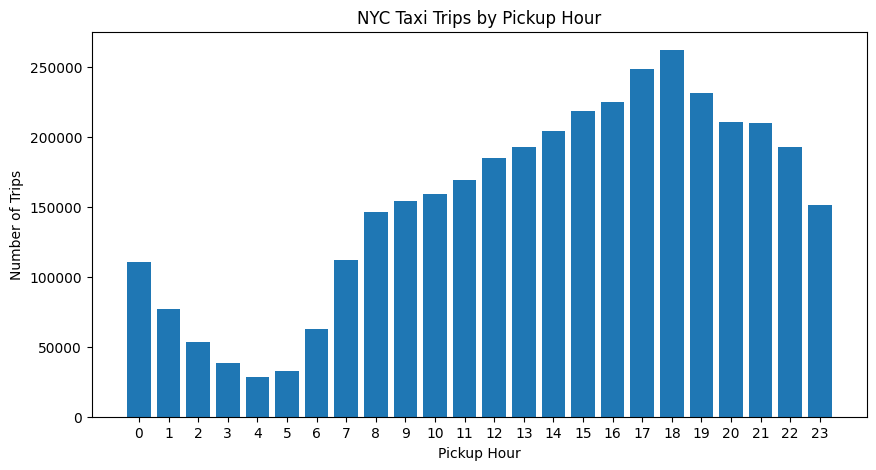

In [66]:
plt.figure(figsize=(10, 5))

plt.bar(
    hourly_trips["pickup_hour"],
    hourly_trips["total_trips"]
)

plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("NYC Taxi Trips by Pickup Hour")
plt.xticks(range(24))

plt.show()

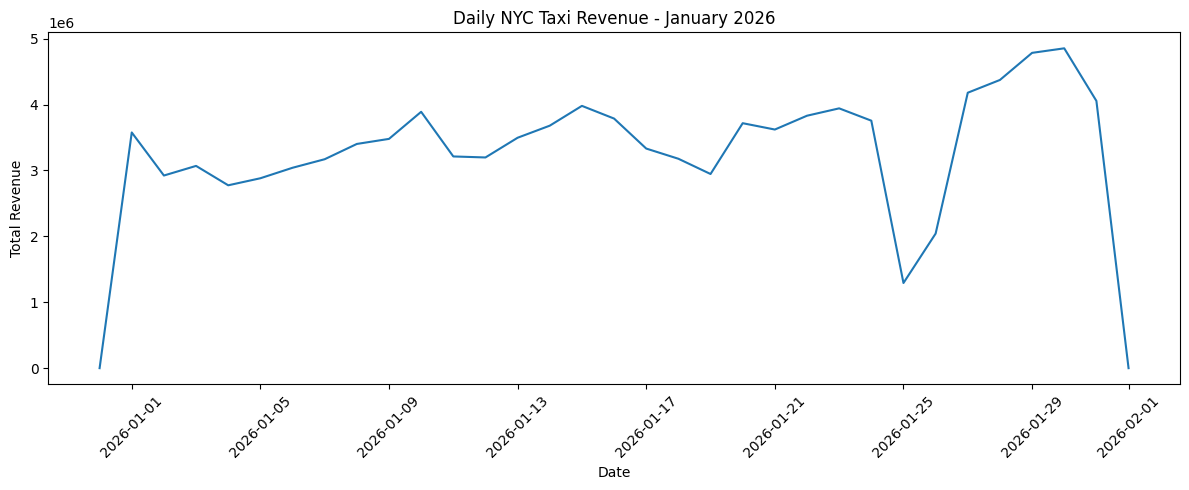

In [67]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_revenue["date"],
    daily_revenue["total_revenue"]
)

plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.title("Daily NYC Taxi Revenue - January 2026")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

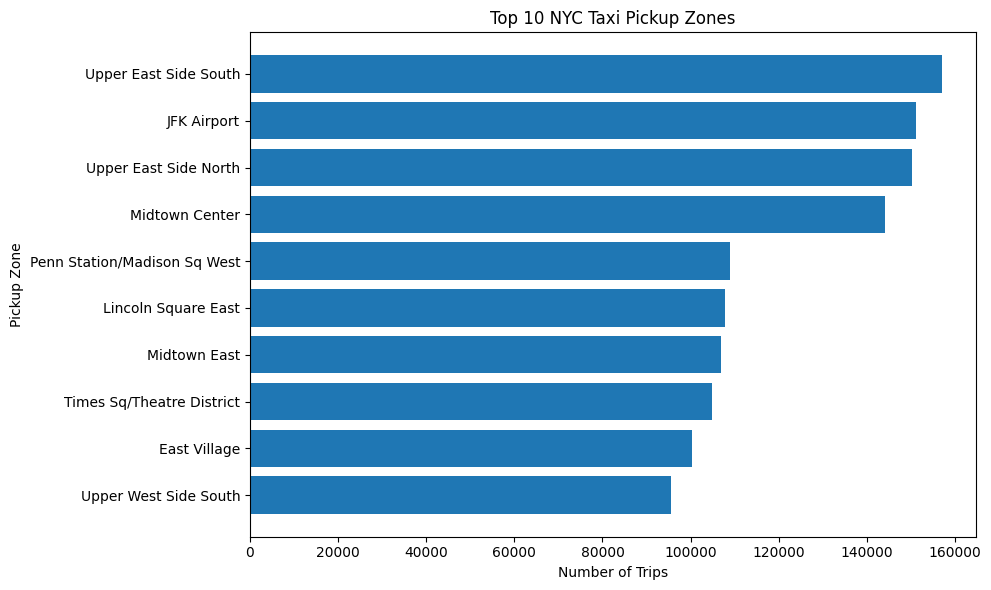

In [68]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_pickup_zones["zone"],
    top_pickup_zones["total_trips"]
)

plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.title("Top 10 NYC Taxi Pickup Zones")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

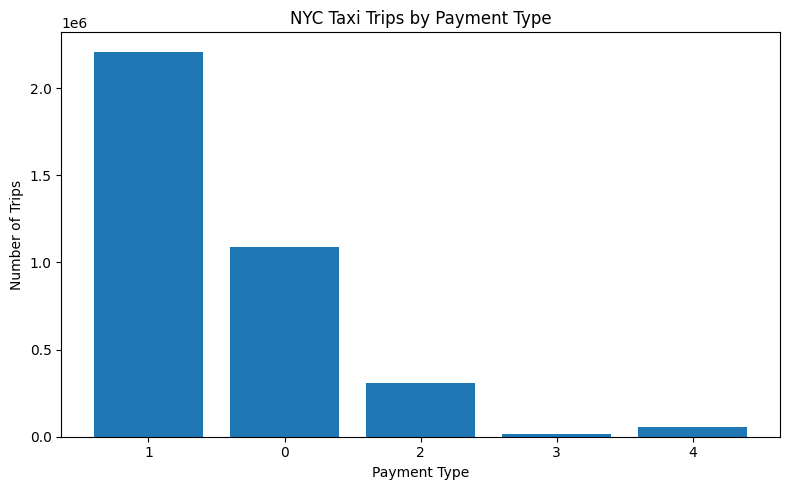

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    payment_analysis["payment_type"].astype(str),
    payment_analysis["total_trips"]
)

plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.title("NYC Taxi Trips by Payment Type")

plt.tight_layout()
plt.show()

## 11. Key Business Insights

- The highest taxi demand occurs during the evening hours, with 18:00 being the busiest pickup hour.
- The lowest number of trips occurs around 04:00.
- Evening peak hours indicate strong demand during commuting and evening travel periods.
- The top pickup zones generate a significant proportion of total taxi trips.
- Payment type analysis provides insight into customer payment preferences.
- Daily revenue analysis helps identify revenue fluctuations throughout the month.

## 12. Final Validation

In [70]:
print("Fact Table Shape:", fact_trip.shape)
print("Date Dimension Shape:", date_dim.shape)
print("Zone Dimension Shape:", dim_zone.shape)

print("\nFact Table Null Values:")
print(fact_trip.isnull().sum().sum())

print("\nFact Table Duplicate Rows:")
print(fact_trip.duplicated().sum())

print("\nDate Key Validation:")
print(
    fact_trip["date_key"].isin(
        date_dim["date_key"]
    ).all()
)

print("\nPickup Location Validation:")
print(
    fact_trip["pickup_location_id"].isin(
        dim_zone["location_id"]
    ).all()
)

print("\nDropoff Location Validation:")
print(
    fact_trip["dropoff_location_id"].isin(
        dim_zone["location_id"]
    ).all()
)

Fact Table Shape: (3678064, 24)
Date Dimension Shape: (33, 7)
Zone Dimension Shape: (265, 4)

Fact Table Null Values:
0

Fact Table Duplicate Rows:
0

Date Key Validation:
True

Pickup Location Validation:
True

Dropoff Location Validation:
True


## 13. Conclusion

The NYC Taxi Data Warehouse successfully integrates NYC Yellow Taxi trip data with date and zone dimensions.

The data warehouse supports efficient SQL-based analysis of taxi demand, revenue, pickup locations, payment methods, and travel patterns.

Data cleaning and transformation were performed using Python and pandas, while SQLite was used to implement the data warehouse. Business insights were extracted using SQL queries and presented through visualizations.

The completed warehouse provides a structured foundation for understanding taxi demand and revenue patterns during January 2026.